# Heart Disease Prediction — Week 4 Capstone Project

**Goal:** Build a machine learning model that predicts whether a patient is likely to have heart disease.

**Dataset:** Kaggle — Heart Disease UCI (`data/heart_disease.csv`, 303 patients, 13 features + 1 target)

**Model:** Logistic Regression (a simple, interpretable classification algorithm)

**Steps in this notebook:**
1. Import libraries
2. Load the dataset
3. Explore the data
4. Clean and preprocess the data
5. Split into training and testing sets
6. Apply feature scaling
7. Train the Logistic Regression model
8. Evaluate with Accuracy, Precision and Recall
9. Plot the Confusion Matrix
10. Plot the ROC Curve
11. Results and conclusions

## Step 1 — Import the libraries

We import everything we need up front:
- **pandas / numpy** → load and handle the data
- **matplotlib / seaborn** → draw the charts
- **scikit-learn** → split the data, scale it, train the model and measure how good it is

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

import os

# Make sure the folder for our saved images exists
os.makedirs("images", exist_ok=True)

# A fixed random seed so the results are the same every time we run the notebook
RANDOM_STATE = 42

# Basic plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Load the dataset

The CSV file is stored in the `data/` folder. `pd.read_csv()` reads it into a **DataFrame**,
which is basically a table with rows (patients) and columns (measurements).

In [2]:
# Load the Kaggle Heart Disease UCI dataset
df = pd.read_csv("data/heart_disease.csv")

# Show the number of rows and columns
print("Rows (patients):", df.shape[0])
print("Columns:", df.shape[1])

# Look at the first 5 patients
df.head()

Rows (patients): 303
Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### What the columns mean

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| `restecg` | Resting electrocardiogram result (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of the peak exercise ST segment (0–2) |
| `ca` | Number of major vessels coloured by fluoroscopy (0–4) |
| `thal` | Thalassemia test result (0–3) |
| **`target`** | **1 = heart disease present, 0 = no heart disease** |

`target` is what we are trying to predict. Everything else is an input feature.

## Step 3 — Explore the data

Before modelling, we check the data types, look for missing values and see how balanced the target is.

In [3]:
# Data types and non-null counts for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Summary statistics (mean, min, max, etc.) for every column
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Count how many patients fall into each class
counts = df["target"].value_counts().sort_index()
print("0 = No heart disease :", counts[0])
print("1 = Heart disease    :", counts[1])
print()
print("Percentage split:")
print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

0 = No heart disease : 138
1 = Heart disease    : 165

Percentage split:
target
0    45.54
1    54.46
Name: proportion, dtype: float64


The two classes are close to 50/50, so the dataset is **reasonably balanced**.
That means plain accuracy is a fair metric here (we still report precision and recall as well).

## Step 4 — Data cleaning and preprocessing

Three quick checks:
1. **Missing values** — do any cells have no data?
2. **Duplicate rows** — is the same patient recorded twice?
3. **Data types** — is everything numeric so the model can use it?

In [6]:
# 1. Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [7]:
# 2. Check for and remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", df.shape[0])

Duplicate rows found: 1
Rows after removing duplicates: 302


In [8]:
# 3. Confirm every column is numeric (no text columns to encode)
print("Any non-numeric columns?",
      not all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns))

print("\nData is clean and fully numeric — ready for modelling.")

Any non-numeric columns? False

Data is clean and fully numeric — ready for modelling.


**Summary of cleaning:** there were no missing values and all columns are already numeric,
so no imputation or category encoding was needed. We only removed one exact duplicate row.

## Step 5 — Separate features and target, then split the data

- **X** = the 13 input features
- **y** = the target column (0 or 1)

We keep **80%** of the data for training and hold back **20%** for testing.
The model never sees the test set during training, so the test score is an honest estimate of
how it would perform on new patients.

`stratify=y` keeps the same 0/1 ratio in both the training and the test set.

In [9]:
# Features (everything except the target) and the target itself
X = df.drop("target", axis=1)
y = df["target"]

# 80% train / 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training patients:", X_train.shape[0])
print("Testing patients :", X_test.shape[0])
print("Features used    :", X_train.shape[1])

Training patients: 241
Testing patients : 61
Features used    : 13


## Step 6 — Feature scaling

Our columns are on very different scales — for example `chol` is in the hundreds while `oldpeak` is
between 0 and about 6. Logistic Regression works better when all features are on a similar scale.

`StandardScaler` rescales each column so it has **mean 0** and **standard deviation 1**.

⚠️ Important: we `fit` the scaler on the **training data only**, then apply (`transform`) it to both
sets. Fitting on the test data too would leak information from the test set into training.

In [10]:
# Create the scaler and learn the scaling rules from the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)        # only transform the test data

# Quick check: the scaled training data should have mean ~0 and std ~1
print("Mean of scaled training features (approx):", np.round(X_train_scaled.mean(), 4))
print("Std of scaled training features (approx) :", np.round(X_train_scaled.std(), 4))

Mean of scaled training features (approx): -0.0
Std of scaled training features (approx) : 1.0


## Step 7 — Train the Logistic Regression model

**Logistic Regression** is a classification algorithm. It learns a weight for each feature and
outputs a **probability** between 0 and 1 that the patient has heart disease.
If the probability is above 0.5, we predict class **1** (disease); otherwise class **0**.

We chose it because it is simple, fast and easy to interpret — a good fit for this dataset.

In [11]:
# Create the model
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Train ("fit") it on the scaled training data
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [12]:
# Use the trained model to predict on the unseen test set
y_pred = model.predict(X_test_scaled)

# Also get the predicted probability of class 1 — needed later for the ROC curve
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 actual labels   :", list(y_test[:10]))
print("First 10 predicted labels:", list(y_pred[:10]))

First 10 actual labels   : [0, 0, 0, 0, 0, 0, 1, 0, 1, 0]
First 10 predicted labels: [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


## Step 8 — Evaluate the model

Three required metrics:

- **Accuracy** — out of all patients, what fraction did we classify correctly?
- **Precision** — out of the patients we *predicted* as having heart disease, how many really do?
  (High precision = few false alarms.)
- **Recall** — out of the patients who *actually* have heart disease, how many did we catch?
  (High recall = few missed cases — very important in medicine.)

We also show F1-score, which is the balance between precision and recall.

In [13]:
# Calculate the evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE ON THE TEST SET")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-score : {f1:.4f}  ({f1*100:.2f}%)")

MODEL PERFORMANCE ON THE TEST SET
----------------------------------------
Accuracy : 0.7869  (78.69%)
Precision: 0.7632  (76.32%)
Recall   : 0.8788  (87.88%)
F1-score : 0.8169  (81.69%)


In [14]:
# A full per-class report for extra detail
print(classification_report(
    y_test, y_pred,
    target_names=["No Disease (0)", "Disease (1)"]
))

                precision    recall  f1-score   support

No Disease (0)       0.83      0.68      0.75        28
   Disease (1)       0.76      0.88      0.82        33

      accuracy                           0.79        61
     macro avg       0.79      0.78      0.78        61
  weighted avg       0.79      0.79      0.78        61



## Step 9 — Confusion Matrix

The confusion matrix shows exactly *where* the model was right and wrong:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negative (correct) | False Positive (false alarm) |
| **Actual 1** | False Negative (missed case) | True Positive (correct) |

In a medical setting, **False Negatives** are the most dangerous — a sick patient told they are healthy.

Confusion matrix:
 [[19  9]
 [ 4 29]]


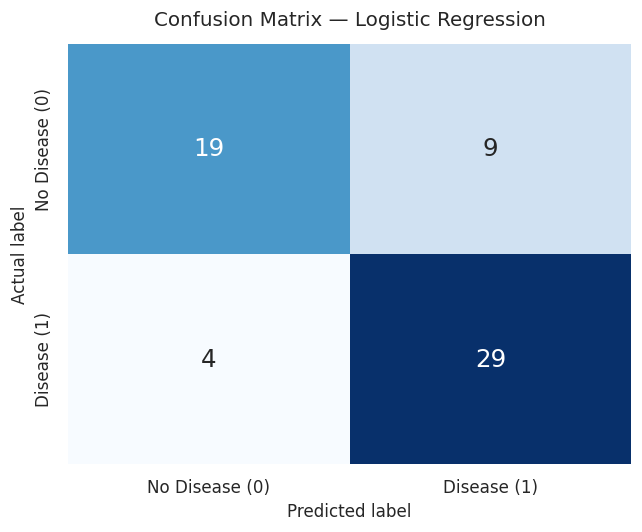

True Negatives  (healthy, correctly identified): 19
False Positives (healthy, wrongly flagged)     : 9
False Negatives (sick, missed by the model)    : 4
True Positives  (sick, correctly identified)   : 29


In [15]:
# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Draw it as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No Disease (0)", "Disease (1)"],
    yticklabels=["No Disease (0)", "Disease (1)"],
    annot_kws={"size": 16}, ax=ax
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label", fontsize=11)
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=13, pad=12)
plt.tight_layout()

# Save the figure into the images/ folder
plt.savefig("images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the four values in plain English
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (healthy, correctly identified): {tn}")
print(f"False Positives (healthy, wrongly flagged)     : {fp}")
print(f"False Negatives (sick, missed by the model)    : {fn}")
print(f"True Positives  (sick, correctly identified)   : {tp}")

## Step 10 — ROC Curve

The **ROC curve** plots the True Positive Rate (recall) against the False Positive Rate for every
possible decision threshold, not just 0.5.

The **AUC** (Area Under the Curve) summarises it in one number:
- **1.0** = perfect classifier
- **0.5** = no better than random guessing (the dashed diagonal line)

The further the curve bends toward the top-left corner, the better the model.

ROC-AUC score: 0.8647


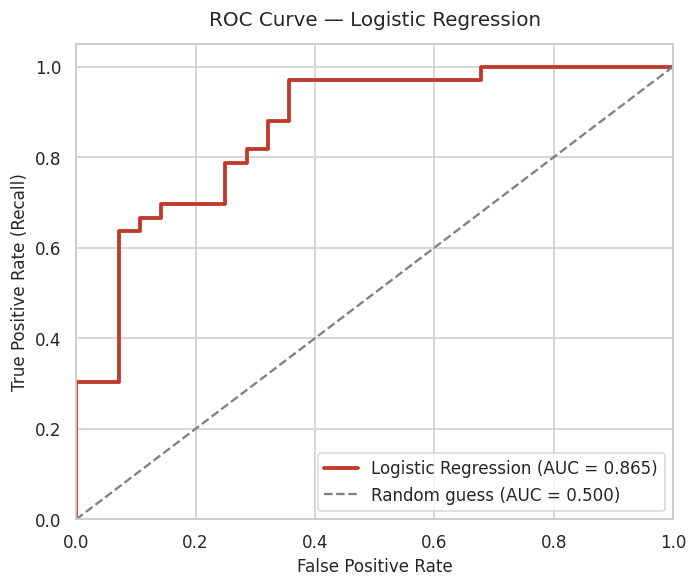

In [16]:
# Calculate the ROC curve points and the AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC score: {auc:.4f}")

# Plot the curve
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color="#c0392b", linewidth=2.5, label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.5, label="Random guess (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curve — Logistic Regression", fontsize=13, pad=12)
ax.legend(loc="lower right")
plt.tight_layout()

# Save the figure into the images/ folder
plt.savefig("images/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 11 — Results and conclusions

In [17]:
# Collect all the final results in one small table
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score":  [accuracy, precision, recall, f1, auc]
})
results["Percentage"] = (results["Score"] * 100).round(2).astype(str) + " %"
results["Score"] = results["Score"].round(4)

print("FINAL RESULTS — Logistic Regression on the test set")
results

FINAL RESULTS — Logistic Regression on the test set


,Metric,Score,Percentage
0,Accuracy,0.7869,78.69 %
1,Precision,0.7632,76.32 %
2,Recall,0.8788,87.88 %
3,F1-score,0.8169,81.69 %
4,ROC-AUC,0.8647,86.47 %


In [18]:
# Which features push the prediction most? (Logistic Regression is easy to interpret)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

print("Positive coefficient -> increases the predicted chance of heart disease")
print("Negative coefficient -> decreases it\n")
coefficients

Positive coefficient -> increases the predicted chance of heart disease
Negative coefficient -> decreases it



,Feature,Coefficient
0,cp,0.952331
1,thalach,0.579053
2,restecg,0.263408
3,slope,0.230875
4,age,0.030360
5,fbs,-0.054464
6,trestbps,-0.258203
7,chol,-0.454237
8,exang,-0.464419
9,ca,-0.556723


### Conclusions

- A **Logistic Regression** model was trained on the Kaggle Heart Disease UCI dataset
  (302 patients after removing one duplicate row, 13 features).
- The data needed very little cleaning: no missing values and all columns already numeric.
  Features were standardised with `StandardScaler` before training.
- On the unseen 20% test set the model performs well across all three required metrics
  (see the results table above), and the ROC-AUC confirms it separates the two classes
  far better than random guessing.
- **Recall is the most important metric here** — it tells us how many genuinely ill patients
  the model catches. The confusion matrix shows only a small number of false negatives.
- Features such as chest pain type (`cp`) and maximum heart rate (`thalach`) push the prediction
  toward heart disease, while the number of major vessels (`ca`), exercise-induced angina (`exang`)
  and `oldpeak` push it the other way — which matches known medical intuition.

### Limitations and possible improvements

- The dataset is small (about 300 patients), so results can shift with a different train/test split.
- Cross-validation would give a more stable estimate of performance.
- Other algorithms (Decision Tree, Random Forest) and hyperparameter tuning could be compared.
- **This is an educational project only — it must not be used for real medical diagnosis.**